#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

#Data

In [3]:
embeddings = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/BulkRNABert_data/bulkrnabert_embeddings.csv', index_col=0)
print(embeddings.shape)
embeddings

(442, 256)


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
MSKC-00397,0.913342,0.621870,0.922743,-1.037893,0.301553,0.715152,0.206450,0.652923,0.059982,0.294590,...,0.175746,-0.133243,0.109954,0.040338,0.067777,1.130643,0.370476,0.344561,-0.118917,0.710770
MSKC-00399,0.818992,0.296598,0.773417,-0.866102,0.307585,0.849735,0.420930,0.668587,-0.094435,-0.175127,...,0.098970,-0.331284,0.045357,-0.092454,-0.062354,1.144853,0.325433,0.280668,-0.220902,0.927439
MSKC-00400,1.022584,0.321305,1.228209,-1.065100,0.499109,0.576022,0.248522,0.579413,-0.226993,0.099416,...,-0.146370,-0.176852,-0.045236,-0.197819,-0.038868,1.062385,0.275921,0.211972,-0.131308,0.676849
MSKC-00404,1.022246,0.744968,1.156375,-1.013309,0.230046,0.506557,0.223892,0.750233,0.054625,0.459118,...,0.257191,-0.178159,0.146739,-0.014896,0.050930,1.156376,0.497806,0.327070,-0.180218,0.540008
MSKC-00405,0.971925,0.678423,0.743625,-1.148056,0.332629,0.655422,0.190903,0.555662,0.075683,0.220108,...,0.057747,-0.262169,-0.035882,-0.028639,0.074571,1.213970,0.348896,0.325905,-0.168206,0.697458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-P44H,0.533675,-0.316429,3.371898,-0.029202,1.088933,0.488736,-0.090113,0.487655,-0.186383,0.200859,...,0.820505,-0.337173,0.678901,-0.616893,-0.337793,0.528891,0.194825,-0.301103,0.193381,0.732298
PT-R55F,0.582715,-0.349183,3.070900,-0.071421,0.945457,0.581417,0.043929,0.615177,-0.309759,0.207503,...,0.907579,-0.257814,0.802587,-0.588829,-0.070505,0.612147,0.205887,-0.325677,0.269320,0.858617
PT-RN5K,0.562467,-0.276826,3.437461,-0.140747,1.013584,0.594322,-0.079603,0.749423,-0.308488,0.279132,...,0.957076,-0.202017,0.776208,-0.609761,-0.075496,0.633105,0.102027,-0.451013,0.353921,0.800787
PT-UTHO,0.593032,-0.350178,2.716498,-0.164287,0.824521,0.557042,0.101592,0.653268,-0.325775,0.185995,...,0.867591,-0.184794,0.821017,-0.624438,-0.057503,0.671240,0.301893,-0.214687,0.284997,0.922281


In [4]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites = metabolites.loc[embeddings.index]
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
print(metabolites.shape)
metabolites.head(3)

(442, 218)


,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
MSKC-00397,22.151250,18.354985,22.463941,20.468435,21.777534,22.886951,21.766380,23.556862,20.373682,22.047978,...,25.553784,23.658074,28.487968,16.955614,24.833037,18.604157,23.239660,15.840222,17.228723,22.396280
MSKC-00399,21.247188,18.111536,22.645598,20.529346,19.739271,21.009891,20.167228,21.002270,18.394891,21.123958,...,24.359559,26.169329,28.564088,16.955614,24.448438,20.819139,24.725409,18.565178,18.696191,23.682378
MSKC-00400,21.760056,15.625641,19.476107,19.097750,18.660445,20.936016,18.433717,18.995415,18.660803,19.339385,...,26.413287,27.040641,28.949443,16.955614,26.111056,19.417787,22.856360,23.065816,17.490103,21.785170


In [5]:
metabolites.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/metabolomics_log2.csv')

#Log2 transformation

In [6]:
embeddings = embeddings.apply(lambda x: np.log2(x + 1))
embeddings.head(3)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
MSKC-00397,0.936094,0.697658,0.943166,NaN,0.380234,0.778337,0.270768,0.725019,0.084039,0.372495,...,0.233577,-0.206301,0.150500,0.057053,0.094610,1.091289,0.454677,0.427135,-0.182651,0.774646
MSKC-00399,0.863139,0.374732,0.826532,-2.900795,0.386905,0.887319,0.506836,0.738627,-0.143111,-0.277756,...,0.136152,-0.580535,0.063996,-0.139958,-0.092884,1.100879,0.406464,0.356896,-0.360123,0.946685
MSKC-00400,1.016199,0.401963,1.155884,NaN,0.584105,0.656288,0.320221,0.659389,-0.371447,0.136738,...,-0.228318,-0.280776,-0.066783,-0.318000,-0.057193,1.044314,0.351539,0.277356,-0.203084,0.745753


#Data shuffling

In [7]:
combined_data = pd.concat([embeddings, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_embeddings = shuffled_data[embeddings.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

embeddings = shuffled_embeddings
metabolites = shuffled_metabolites

#Data imputation and normalization [-1, 1]

In [8]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [9]:
X = embeddings.fillna(0).values
y = metabolites.values

In [10]:
print(X.shape)
print(y.shape)

(442, 256)
(442, 218)


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (353, 256)
min: -1.0
max: 1.0
shape: (44, 256)
min: -1.0
max: 1.0
shape: (45, 256)
min: -1.0
max: 1.0
shape: (353, 218)
min: -1.0
max: 1.0
shape: (44, 218)
min: -1.0
max: 1.0
shape: (45, 218)
Train data:
(353, 256)
(353, 218)
Test data:
(44, 256)
(44, 218)
Val data:
(45, 256)
(45, 218)


In [12]:
# !pip install keras-tuner --quiet
# import keras_tuner as kt
# from tensorflow.keras import layers, Sequential

# # def model_builder(hp):
# #   model = keras.Sequential()
# #   model.add(layers.Input(shape=(X_train.shape[1],)))

# #   # Tune the number of units in the first Dense layer
# #   # Choose an optimal value between 32-512
# #   hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
# #   model.add(keras.layers.Dense(units=hp_units, activation='relu'))
# #   model.add(layers.Dense(y_train.shape[1], activation='linear'))

# #   # Tune the learning rate for the optimizer
# #   # Choose an optimal value from 0.01, 0.001, or 0.0001
# #   hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

# #   model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
# #                 loss='mse', # Changed loss to 'mse' for regression
# #                 metrics=['mae']) # Changed metric to 'mae' for regression

# #   return model

# def model_builder(hp):
#     model = Sequential()
#     model.add(layers.Dense(
#         # Search for optimal number of units in the first hidden layer
#         hp.Int('units_1', min_value=32, max_value=512, step=32),
#         activation='relu',
#         input_shape=(X_train.shape[1],)
#     ))
#     # Optional: Search for additional layers and dropout
#     if hp.Boolean('dropout'):
#         model.add(layers.Dropout(rate=0.25))

#     # --- CRITICAL: Multi-Output Regression Head ---
#     # The output layer size is fixed to NUM_OUTPUTS and activation is 'linear'
#     model.add(layers.Dense(y_train.shape[1], activation='linear', name='regression_output'))

#     model.compile(
#         optimizer=hp.Choice('optimizer', values=['adam', 'sgd']),
#         # Use MSE as the loss for multi-output regression
#         loss='mse',
#         metrics=['mse', 'mae']
#     )
#     return model

# tuner = kt.Hyperband(model_builder,
#                      objective='val_loss',
#                      max_epochs=10,
#                      factor=3,
#                      directory='my_dir',
#                      project_name='intro_to_kt')
# stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# tuner.search(X_train, y_train, epochs=50, validation_data = (X_val, y_val), callbacks=[stop_early])

# best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
# print(f"""
# The hyperparameter search is complete. The optimal number of units in the first densely-connected
# layer is {best_hps.get('units_1')} and the optimal optimizer
# is {best_hps.get('optimizer')}.
# """)

# model = tuner.hypermodel.build(best_hps)
# model.summary()

# history = model.fit(X_train, y_train, epochs=50, validation_data = (X_val, y_val))

# val_acc_per_epoch = history.history['val_loss']
# best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
# print('Best epoch: %d' % (best_epoch,))

# hypermodel = tuner.hypermodel.build(best_hps)

# # Retrain the model
# hypermodel.fit(X_train, y_train, epochs=best_epoch, validation_split=0.2)

# eval_result = hypermodel.evaluate(X_train, y_train)
# print("[test loss, test accuracy]:", eval_result)

# model = hypermodel

In [13]:
from tensorflow.keras import layers, Sequential, regularizers

model = Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(y_train.shape[1], activation='linear')
])

model.compile(optimizer = 'adam',
              loss = 'mse',
              metrics = ['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,026 (218.85 KB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=32,
                    validation_data = (X_val, y_val),
                    shuffle = True,
                    callbacks = [tf.keras.callbacks.EarlyStopping(patience = 100, restore_best_weights=True)])

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.2618 - mae: 0.3891 - val_loss: 0.0911 - val_mae: 0.2407
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0935 - mae: 0.2415 - val_loss: 0.0855 - val_mae: 0.2343
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0687 - mae: 0.2128 - val_loss: 0.0836 - val_mae: 0.2317
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0631 - mae: 0.2004 - val_loss: 0.0798 - val_mae: 0.2235
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0595 - mae: 0.1848 - val_loss: 0.0773 - val_mae: 0.2232
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0603 - mae: 0.1929 - val_loss: 0.0773 - val_mae: 0.2208
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0558 - mae: 0.1801 - val_loss: 0.0746 - val_mae: 0.2201
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0574 - mae: 0.1920 - val_loss: 0.0727 - val_mae: 0.2129
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - l

In [15]:
model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/bulkrnabert_regression_head.keras')

In [16]:
import pickle

model_features_output = metabolites.columns.to_list()

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/bulkrnabert_regression_head_model_features_output.pkl', 'wb') as f:
    pickle.dump(model_features_output, f)

In [17]:
loss, mae = model.evaluate(X_test, y_test)
print('mae')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.0324 - mae: 0.1390
mae


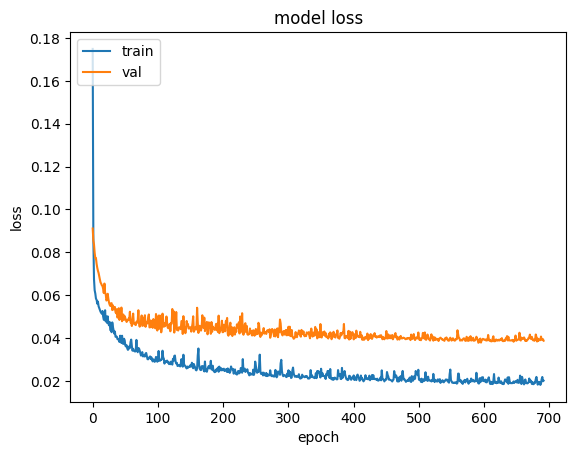

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [19]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0201
Training MAE: 0.1052


In [20]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0388
Validation MAE: 0.1513


In [21]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0335
Test MAE: 0.1407


In [22]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


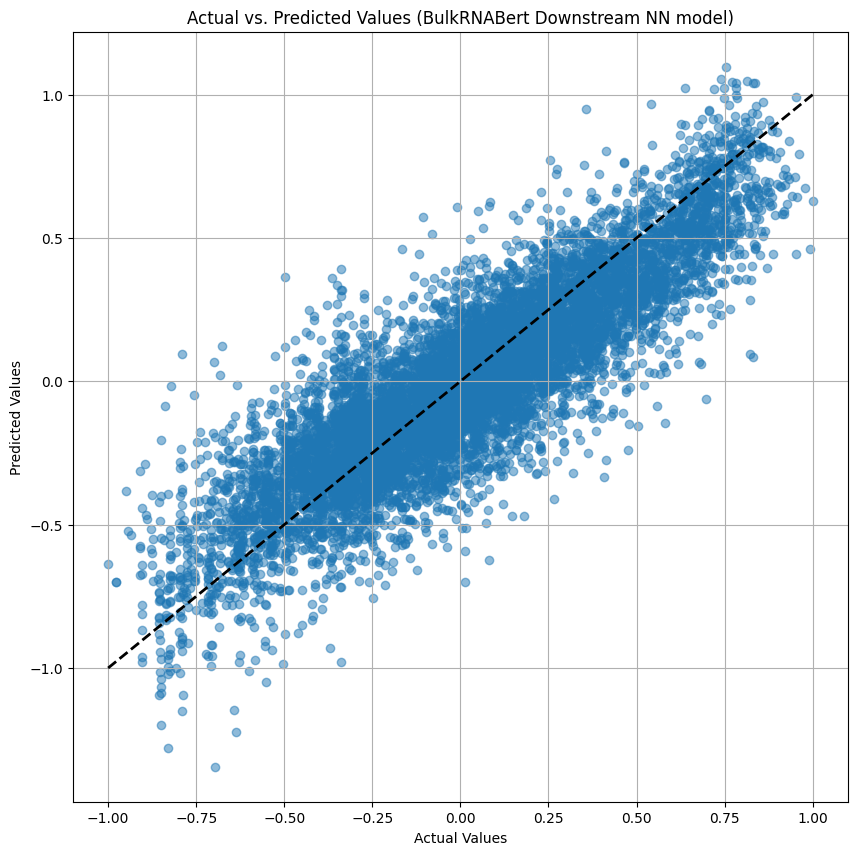

In [23]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'k--', lw=2, label='Ideal')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (BulkRNABert Downstream NN model)")
plt.grid(True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_scatter.svg', bbox_inches = 'tight')
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [25]:
get_metrics(y_predicted = predictions)

MSE: 0.033522315323352814
MAE: 0.14073270559310913
MedAE: 0.11719436
Mean absolute percentage error: 179.06024


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


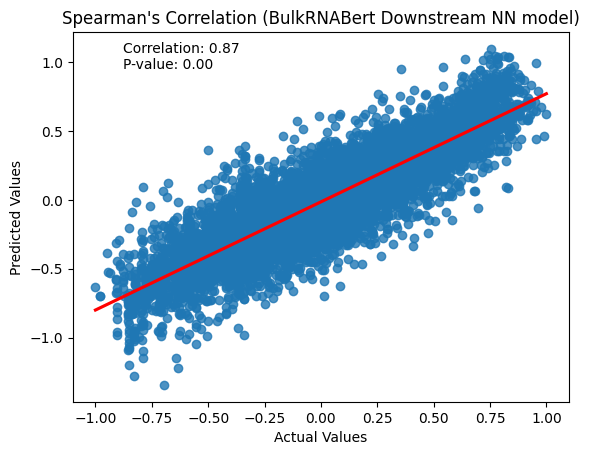

In [26]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation (BulkRNABert Downstream NN model)')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_spearman.svg', bbox_inches = 'tight')
  plt.show()


get_spearman_correlation(predictions)

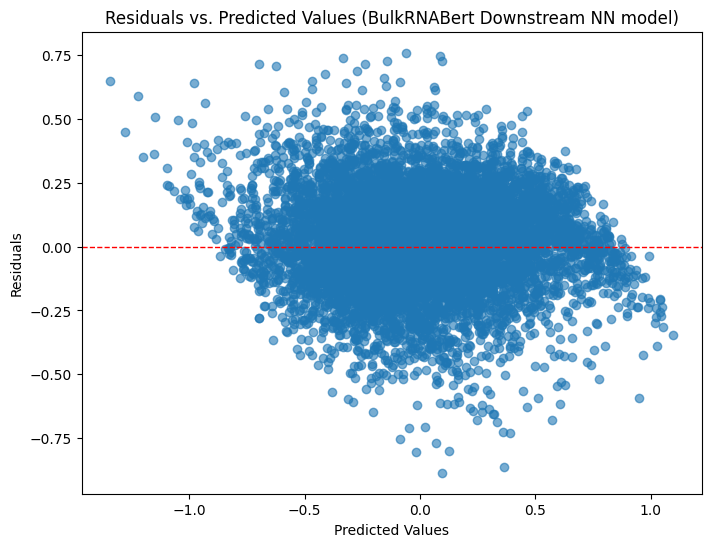

In [27]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions):

  residuals = (y_test - model_predictions).ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values (BulkRNABert Downstream NN model)")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_residuals.svg', bbox_inches = 'tight')
  plt.show()

get_residuals_vs_pred_plot(predictions)

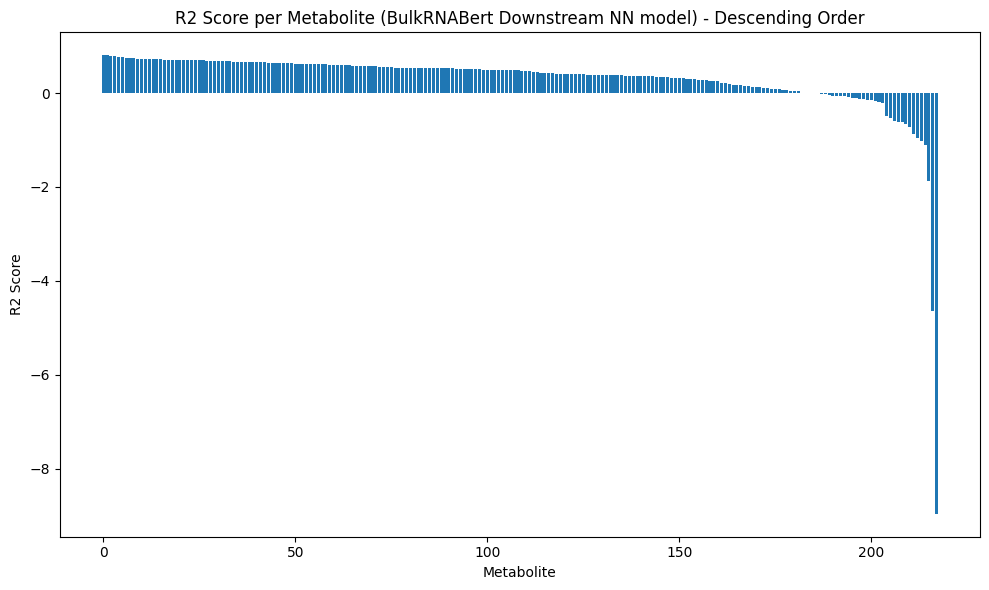

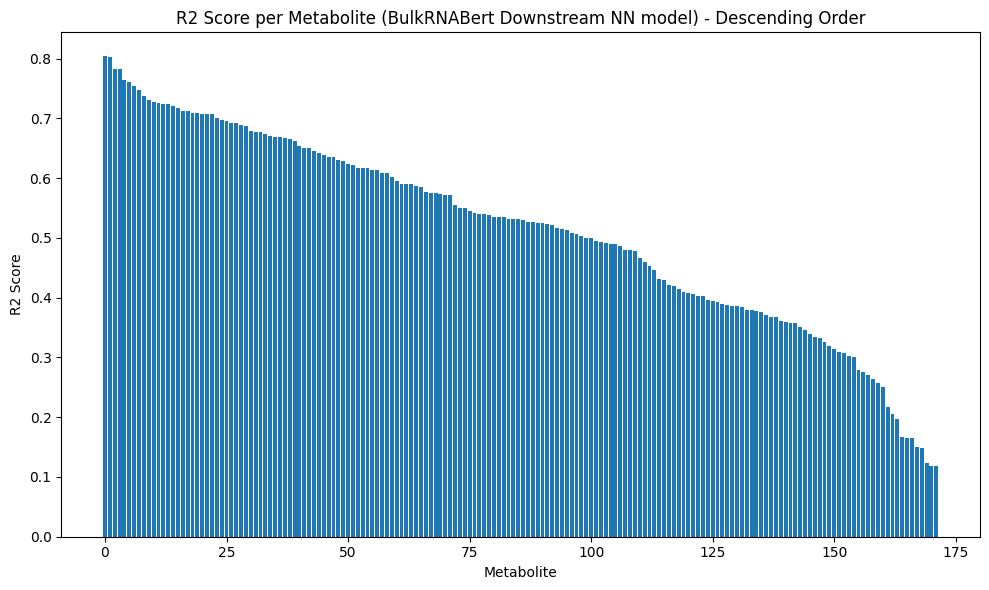

In [28]:
from sklearn.metrics import r2_score

def plot_r2_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the R2 score per metabolite for a given model in descending order."""

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Calculate R2 for the current metabolite across all samples
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': metabolite_names, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)
    r2_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/r2_df_BulkRNABert_nn.csv', index =True)
    r2_df_filtered = r2_df[r2_df['R2 Score'] > 0.1]

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite (BulkRNABert Downstream NN model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_r2.svg', bbox_inches = 'tight')
    plt.show()

    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df_filtered)), r2_df_filtered['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite (BulkRNABert Downstream NN model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_r2_filtered.svg', bbox_inches = 'tight')
    plt.show()

# Get the original metabolite names before splitting and normalization
original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_r2_per_metabolite(y_test, predictions, original_metabolite_names)

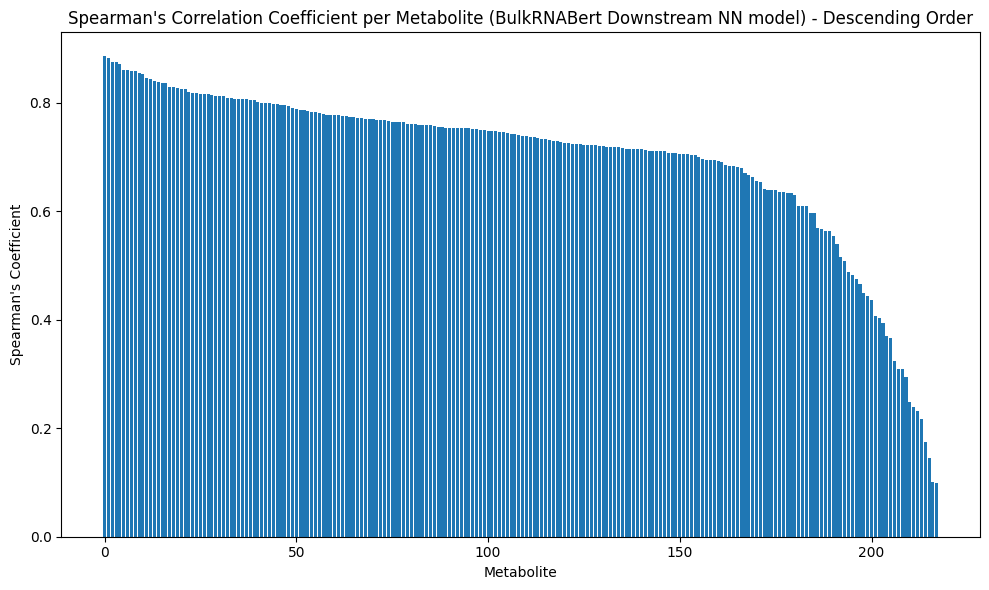

In [29]:
def plot_spearman_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Ensure y_true and y_pred for the current metabolite are 1D arrays
        coeff, _ = spearmanr(y_true[:, i].ravel(), y_pred[:, i].ravel())  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting using metabolite names
    spearman_df = pd.DataFrame({'Metabolite': metabolite_names, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)
    spearman_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/spearman_df_bulkrnabert_nn.csv', index = True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    # Use the metabolite names from the sorted DataFrame for x-axis labels
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names and rotate them
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite (BulkRNABert Downstream NN model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BulkRNABert_downstream_nn_spearman_coeff_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_spearman_per_metabolite(y_test, predictions, original_metabolite_names)